# Missão Aurora Siger | Relatório Operacional de Pré-Decolagem

Atividade Integradora, Fase 1 (FIAP). Grupo 30: Jean Melo.

Este notebook lê a telemetria da nave Aurora, aplica o algoritmo de verificação, calcula a autonomia energética e decide entre **PRONTO PARA DECOLAR** e **DECOLAGEM ABORTADA**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import pandas as pd
import matplotlib.pyplot as plt
import aurora
from aurora import ler_telemetria, verificar_leitura, analise_energetica, carga_minima_para_reserva
CSV = '../data/telemetria_aurora.csv'

## 1.1 Organização e descrição da telemetria

| Coluna | Descrição | Unidade / tipo | Faixa segura |
|---|---|---|---|
| `leitura_id` | Identificador da leitura | texto | |
| `janela` | Momento da contagem regressiva | T-min | |
| `temp_interna_c` | Temperatura da cabine | °C | 18 a 27 |
| `temp_externa_c` | Temperatura do ambiente de lançamento | °C | -90 a 60 |
| `integridade_estrutural` | Integridade do casco (booleano) | 0/1 | 1 |
| `nivel_energia_pct` | Carga das baterias | % | 85 a 100 |
| `pressao_tanque_bar` | Pressão dos tanques de propelente | bar | 190 a 220 |
| `mod_*` | Status dos 4 módulos críticos | OK/FALHA | OK |

In [2]:
df = pd.read_csv(CSV)
print(df.shape)
df.head(10)

(20, 11)


,leitura_id,janela,temp_interna_c,temp_externa_c,integridade_estrutural,nivel_energia_pct,pressao_tanque_bar,mod_propulsao,mod_navegacao,mod_suporte_vida,mod_comunicacao
0,L001,T-20min,23.5,-81.5,1,89.6,197.8,OK,OK,OK,OK
1,L002,T-19min,24.2,9.7,1,97.6,194.3,OK,OK,OK,OK
2,L003,T-18min,22.0,-80.8,1,88.8,205.1,OK,OK,OK,OK
3,L004,T-17min,19.2,-57.2,1,94.4,206.2,OK,OK,OK,OK
4,L005,T-16min,20.5,-2.5,1,96.5,192.2,OK,OK,OK,OK
5,L006,T-15min,24.6,12.7,1,90.4,196.0,OK,OK,OK,OK
6,L007,T-14min,25.7,-37.9,1,87.2,194.5,OK,OK,OK,OK
7,L008,T-13min,24.9,-0.5,1,96.5,211.0,OK,OK,OK,OK
8,L009,T-12min,22.8,51.2,1,72.4,206.4,OK,OK,OK,OK
9,L010,T-11min,24.8,1.6,0,97.2,207.0,OK,OK,OK,OK


In [3]:
df.describe().round(2)

,temp_interna_c,temp_externa_c,integridade_estrutural,nivel_energia_pct,pressao_tanque_bar
count,20.00,20.00,20.00,20.00,20.00
mean,23.79,-14.72,0.95,90.12,202.94
std,3.23,45.84,0.22,6.16,12.49
min,19.20,-81.50,0.00,72.40,176.00
25%,21.12,-48.72,1.00,87.90,194.45
50%,23.85,-11.65,1.00,90.00,203.50
75%,24.95,13.80,1.00,94.43,208.30
max,31.80,78.00,1.00,97.60,234.00


In [4]:
modulos = list(aurora.MODULOS_CRITICOS)
df[modulos].apply(pd.Series.value_counts).fillna(0).astype(int)

,mod_propulsao,mod_navegacao,mod_suporte_vida,mod_comunicacao
FALHA,1,0,1,1
OK,19,20,19,19


## 1.2 Algoritmo de verificação

O fluxograma e o pseudocódigo completos estão em `docs/algoritmo/`. Resumo da lógica: cada leitura começa com uma lista de falhas vazia; cada regra violada adiciona uma falha; se a lista terminar vazia, a nave está **PRONTA**, caso contrário a decolagem é **ABORTADA**.

![Fluxograma](../assets/fluxograma.png)

## 1.3 Script em Python

Faixas seguras usadas pelo módulo `src/aurora.py`:

In [5]:
pd.DataFrame([(k, v[0], v[1]) for k, v in aurora.FAIXAS_SEGURAS.items()],
             columns=['variavel', 'minimo', 'maximo'])

,variavel,minimo,maximo
0,temp_interna_c,18.0,27.0
1,temp_externa_c,-90.0,60.0
2,nivel_energia_pct,85.0,100.0
3,pressao_tanque_bar,190.0,220.0


In [6]:
leituras = ler_telemetria(CSV)
resultados = []
for l in leituras:
    decisao, falhas = verificar_leitura(l)
    resultados.append({'leitura_id': l['leitura_id'], 'janela': l['janela'],
                       'decisao': decisao, 'falhas': '; '.join(falhas) or '-'})
res = pd.DataFrame(resultados)
res

,leitura_id,janela,decisao,falhas
0,L001,T-20min,PRONTO PARA DECOLAR,-
1,L002,T-19min,PRONTO PARA DECOLAR,-
2,L003,T-18min,PRONTO PARA DECOLAR,-
3,L004,T-17min,PRONTO PARA DECOLAR,-
4,L005,T-16min,PRONTO PARA DECOLAR,-
5,L006,T-15min,PRONTO PARA DECOLAR,-
6,L007,T-14min,PRONTO PARA DECOLAR,-
7,L008,T-13min,PRONTO PARA DECOLAR,-
8,L009,T-12min,DECOLAGEM ABORTADA,Nivel de energia (%) abaixo do minimo: 72.4 < ...
9,L010,T-11min,DECOLAGEM ABORTADA,Integridade estrutural comprometida (0)


In [7]:
print(res['decisao'].value_counts().to_string())
final = res.iloc[-1]
print(f"\nSTATUS FINAL ({final['leitura_id']}, {final['janela']}): {final['decisao']}")

decisao
PRONTO PARA DECOLAR    11
DECOLAGEM ABORTADA      9

STATUS FINAL (L020, T-1min): PRONTO PARA DECOLAR


Execução do script completo pelo terminal (`python3 src/verificacao.py`):

In [8]:
import subprocess
print(subprocess.run([sys.executable, '../src/verificacao.py'], capture_output=True, text=True).stdout)

 MISSAO AURORA SIGER | VERIFICACAO DE PRE-DECOLAGEM
Leituras carregadas: 20

[OK] L001 ( T-20min) -> PRONTO PARA DECOLAR | margem   921.6 kWh
[OK] L002 ( T-19min) -> PRONTO PARA DECOLAR | margem  1289.6 kWh
[OK] L003 ( T-18min) -> PRONTO PARA DECOLAR | margem   884.8 kWh
[OK] L004 ( T-17min) -> PRONTO PARA DECOLAR | margem  1142.4 kWh
[OK] L005 ( T-16min) -> PRONTO PARA DECOLAR | margem  1239.0 kWh
[OK] L006 ( T-15min) -> PRONTO PARA DECOLAR | margem   958.4 kWh
[OK] L007 ( T-14min) -> PRONTO PARA DECOLAR | margem   811.2 kWh
[OK] L008 ( T-13min) -> PRONTO PARA DECOLAR | margem  1239.0 kWh
[X]  L009 ( T-12min) -> DECOLAGEM ABORTADA | margem   130.4 kWh
       - Nivel de energia (%) abaixo do minimo: 72.4 < 85.0
       - Reserva energetica insuficiente: 130.4 kWh < 500 kWh
[X]  L010 ( T-11min) -> DECOLAGEM ABORTADA | margem  1271.2 kWh
       - Integridade estrutural comprometida (0)
[X]  L011 ( T-10min) -> DECOLAGEM ABORTADA | margem   894.0 kWh
       - Temperatura interna (C) acima d

## 1.4 Análise energética

Parâmetros da nave: capacidade total **5.000 kWh**, consumo estimado na decolagem **3.200 kWh**, perdas energéticas **8%**, consumo dos sistemas após a decolagem **45 kW** e reserva mínima **500 kWh**.

- energia armazenada = capacidade × carga / 100
- perdas = armazenada × 8%
- energia útil = armazenada − perdas
- margem = energia útil − consumo na decolagem
- autonomia (h) = margem / 45 kW

**Exemplo (L001, carga 89,6%):** 5000 × 0,896 = 4480 kWh; perdas = 358,4 kWh; útil = 4121,6 kWh; margem = 921,6 kWh; autonomia = 20,48 h.

In [9]:
en = pd.DataFrame([{'leitura_id': l['leitura_id'], **analise_energetica(l['nivel_energia_pct'])}
                   for l in leituras])
en

,leitura_id,carga_pct,armazenada_kwh,perdas_kwh,util_kwh,margem_kwh,autonomia_h
0,L001,89.6,4480.0,358.4,4121.6,921.6,20.48
1,L002,97.6,4880.0,390.4,4489.6,1289.6,28.66
2,L003,88.8,4440.0,355.2,4084.8,884.8,19.66
3,L004,94.4,4720.0,377.6,4342.4,1142.4,25.39
4,L005,96.5,4825.0,386.0,4439.0,1239.0,27.53
5,L006,90.4,4520.0,361.6,4158.4,958.4,21.30
6,L007,87.2,4360.0,348.8,4011.2,811.2,18.03
7,L008,96.5,4825.0,386.0,4439.0,1239.0,27.53
8,L009,72.4,3620.0,289.6,3330.4,130.4,2.90
9,L010,97.2,4860.0,388.8,4471.2,1271.2,28.25


In [10]:
print('Carga minima para decolar mantendo a reserva:', carga_minima_para_reserva(), '%')
print('Autonomia media apos a decolagem:', round(en['autonomia_h'].mean(), 2), 'h')

Carga minima para decolar mantendo a reserva: 80.43 %
Autonomia media apos a decolagem: 21.01 h


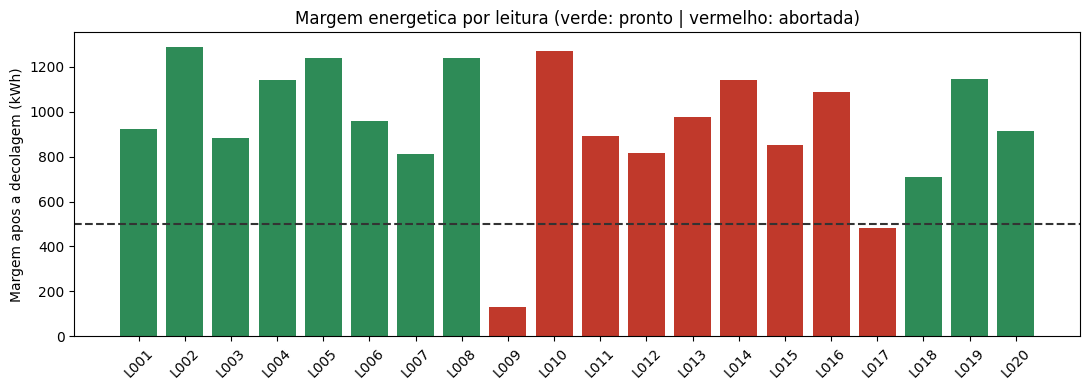

In [11]:
cores = ['#2E8B57' if d == aurora.PRONTO else '#C0392B' for d in res['decisao']]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(en['leitura_id'], en['margem_kwh'], color=cores)
ax.axhline(aurora.RESERVA_MINIMA_KWH, ls='--', color='#333')
ax.set_ylabel('Margem apos a decolagem (kWh)')
ax.set_title('Margem energetica por leitura (verde: pronto | vermelho: abortada)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 1.5 Análise assistida por IA

O prompt e a resposta completa estão em `docs/analise_ia.md`. Abaixo, a classificação sugerida pela IA (NOMINAL, ATENÇÃO, CRÍTICA) reproduzida em código para conferência.

In [12]:
def classificar(l):
    decisao, _ = verificar_leitura(l)
    if decisao == aurora.ABORTADA:
        return 'CRITICA'
    no_limite = any(l[c] in (mn, mx) for c, (mn, mx, _) in aurora.FAIXAS_SEGURAS.items())
    return 'ATENCAO' if no_limite else 'NOMINAL'

res['classe_ia'] = [classificar(l) for l in leituras]
res.groupby('classe_ia')['leitura_id'].apply(list)

classe_ia
ATENCAO                                   [L018, L019, L020]
CRITICA    [L009, L010, L011, L012, L013, L014, L015, L01...
NOMINAL     [L001, L002, L003, L004, L005, L006, L007, L008]
Name: leitura_id, dtype: object

Principais anomalias apontadas: energia insuficiente (L009, L017), falha estrutural (L010), superaquecimento correlacionado com calor externo (L011, L016), oscilação improvável de pressão entre L012 e L013 (possível falha de sensor), falhas de módulos críticos (L014, L015, L017) e instabilidade da sequência (a nave volta a ficar PRONTA logo após nove abortos).

Sugestões: hierarquia de severidade, janela de estabilidade de 3 leituras, estado de ATENÇÃO, redundância de sensores e verificação da taxa de variação.

In [13]:
# Sugestao da IA aplicada: janela de estabilidade (3 leituras aprovadas seguidas)
ult = res['decisao'].tail(3).tolist()
print('Ultimas 3 leituras:', ult)
print('Liberacao com janela de estabilidade:', aurora.PRONTO if all(d == aurora.PRONTO for d in ult) else aurora.ABORTADA)

Ultimas 3 leituras: ['PRONTO PARA DECOLAR', 'PRONTO PARA DECOLAR', 'PRONTO PARA DECOLAR']
Liberacao com janela de estabilidade: PRONTO PARA DECOLAR


## 1.6 Reflexão crítica

O texto completo está em `docs/reflexao_critica.md` e aborda ética e responsabilidade, impacto social da exploração espacial e sustentabilidade tecnológica.

## Conclusão

O algoritmo aprovou 11 leituras e abortou 9, sempre informando o motivo. A leitura mais recente (L020) está **PRONTA PARA DECOLAR**, inclusive considerando a janela de estabilidade sugerida pela IA.